---

# Kuan-Chen Chen, Lab4 3/15/2025


### I strongly recommend you to use HiPerGator to solve this assignment

### Import Libraries and magics

In [70]:
# load libraries and magics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

---

# Exercise 1 (15 points)

**Consider the [breast cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) with 30 numerical attributes described below and a total of 569 samples. Each sample is labeled as malignant (class 0) or benign (class 1). This is a _binary classification task_.**

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(return_X_y=False, as_frame=True)

print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
X = cancer.data

X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
t = cancer.target

t

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64













To access the parameters of the SVM classifier within a pipeline, use the `named_steps` attribute and index it by the name of that step in the pipeline. For example:

```python
final_model.named_steps['svm'].coef_


1. (2 point) Partition the data into training and test sets (80/20 stratified split).

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=2025, stratify=cancer.target
)

In [29]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((455, 30), (114, 30), (455,), (114,))

2. (3 points) Build a scikit-learn pipeline to train an SVM classifier:
- **Hard margin SVM**: Use a linear kernel and a very large `C` to enforce a strict separation.
- **Soft margin SVM**: Use a linear kernel but tune `C` to allow some misclassification.

In [30]:
hard_margin_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1000, random_state=2025))
])

In [31]:
soft_margin_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=2025))  
])

3. (4 points) Carry out hyperparameter tuning (`C` values for soft margin) using cross-validation and train your final model.

In [34]:
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100,1000]}

grid_search = GridSearchCV(
    soft_margin_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'svm__C': 0.1}
Best cross-validation score: 0.9846


In [36]:
hard_margin_pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1000, kernel='linear', random_state=2025))])

In [39]:
soft_margin_model = grid_search.best_estimator_
soft_margin_model

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=0.1, kernel='linear', random_state=2025))])

4. (3 points) Make predictions for training and test sets. Report performance measures using the `classification_report` function.

In [41]:
print("\nHard Margin SVM Performance (C=1000):")
print("\nTraining Set Evaluation:")
y_train_pred_hard = hard_margin_pipeline.predict(x_train)
print(classification_report(y_train, y_train_pred_hard))

print("Test Set Evaluation:")
y_test_pred_hard = hard_margin_pipeline.predict(x_test)
print(classification_report(y_test, y_test_pred_hard))


Hard Margin SVM Performance (C=1000):

Training Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00       285

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

Test Set Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90        42
           1       0.91      0.99      0.95        72

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



In [43]:
print(f"\nSoft Margin SVM Performance (C={grid_search.best_params_['svm__C']}):")
print("\nTraining Set Evaluation:")
y_train_pred_soft = soft_margin_model.predict(x_train)
print(classification_report(y_train, y_train_pred_soft))

print("Test Set Evaluation:")
y_test_pred_soft = soft_margin_model.predict(x_test)
print(classification_report(y_test, y_test_pred_soft))



Soft Margin SVM Performance (C=0.1):

Training Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       170
           1       0.99      1.00      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455

Test Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        42
           1       0.91      1.00      0.95        72

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



5. (3 points) Which features are most informative for the final prediction?
- Access the feature importance via `coef_` in the trained SVM model.


Top 10 Most Important Features:
                 Feature  Importance
21         worst texture    0.437964
27  worst concave points    0.377880
10          radius error    0.376526
26       worst concavity    0.367754
12       perimeter error    0.364090
28        worst symmetry    0.338137
24      worst smoothness    0.334747
15     compactness error    0.333427
6         mean concavity    0.325638
22       worst perimeter    0.312135


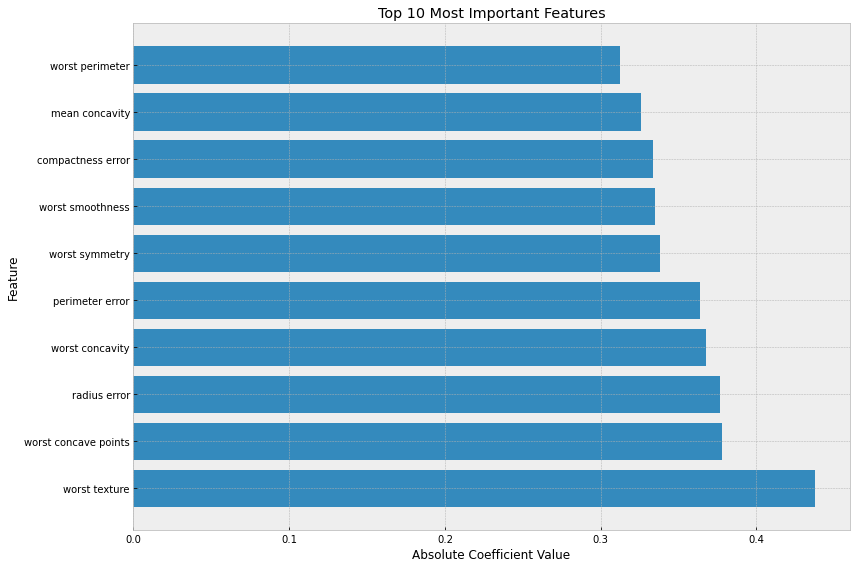

In [45]:
feature_importance = soft_margin_model.named_steps['svm'].coef_[0]
feature_names = cancer.feature_names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(feature_importance) 
})

importance_df = importance_df.sort_values('Importance', ascending=False)


print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

---

# Exercise 2 (15 points)

**In this problem you will work with the [Immunotherapy dataset](https://archive.ics.uci.edu/ml/datasets/Immunotherapy+Dataset).**

**This dataset contains information about wart treatment results of 90 patients using immunotherapy. There are 7 features (sex, age, time, number of warts, type, area and induration diameter). The target label is the column "Result_of_Treatment", where 0 means not successful and 1 means the treatment was successful.**

In [46]:
import pandas as pd

df = pd.read_csv('Immunotherapy.csv')

df

,sex,age,Time,Number_of_Warts,Type,Area,induration_diameter,Result_of_Treatment
0,1,22,2.25,14,3,51,50,1
1,1,15,3.00,2,3,900,70,1
2,1,16,10.50,2,1,100,25,1
3,1,27,4.50,9,3,80,30,1
4,1,20,8.00,6,1,45,8,1
...,...,...,...,...,...,...,...,...
85,1,40,5.50,8,3,69,5,1
86,1,38,7.50,8,2,56,45,1
87,1,46,11.50,4,1,91,25,0
88,1,32,12.00,9,1,43,50,0


**Answer the following questions:**

1. (2 points) **Partition the data into training and test using a stratified 80/20 partition. For reproducible, fix the value for the ```random_state``` parameter.**







In [48]:
x = df.drop('Result_of_Treatment', axis=1)
y = df['Result_of_Treatment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2025, stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((72, 7), (18, 7), (72,), (18,))

2. (5 points) **Build a pipeline that includes data preprocessing and a decision tree classifier with ```random_state=0```.**
    * **For data preprocessing, use one-hot encoding for categorical attributes (```sex``` and ``` Type```) and min-max scaling for all other numerical attributes. Use the ```ColumnTransform``` function.**


In [51]:
categorical_cols = ['sex', 'Type']
numerical_cols = ['age', 'Time', 'Number_of_Warts', 'Area', 'induration_diameter']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', MinMaxScaler(), numerical_cols)
    ])


pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=0))
])


3. (4 points) **Carry hyperparameter tuning using grid search to experiment with ```criterion```, ```max_depth```, ```min_samples_split``` and ```min_samples_leaf```. Train the final model pipeline.**


In [53]:
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_pipe = grid_search.best_estimator_

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}


In [54]:

def get_feature_names(column_transformer):
    """Get feature names from all transformers."""
    feature_names = []
    
    for name, trans, cols in column_transformer.transformers_:
        if name != 'remainder':
            if hasattr(trans, 'get_feature_names_out'):
                feature_names.extend(trans.get_feature_names_out(cols))
            elif hasattr(trans, 'get_feature_names'):
                feature_names.extend(trans.get_feature_names(cols))
            else:
                feature_names.extend(cols)
    
    return feature_names

4. (2 points) **Visualize the resulting decision tree.**

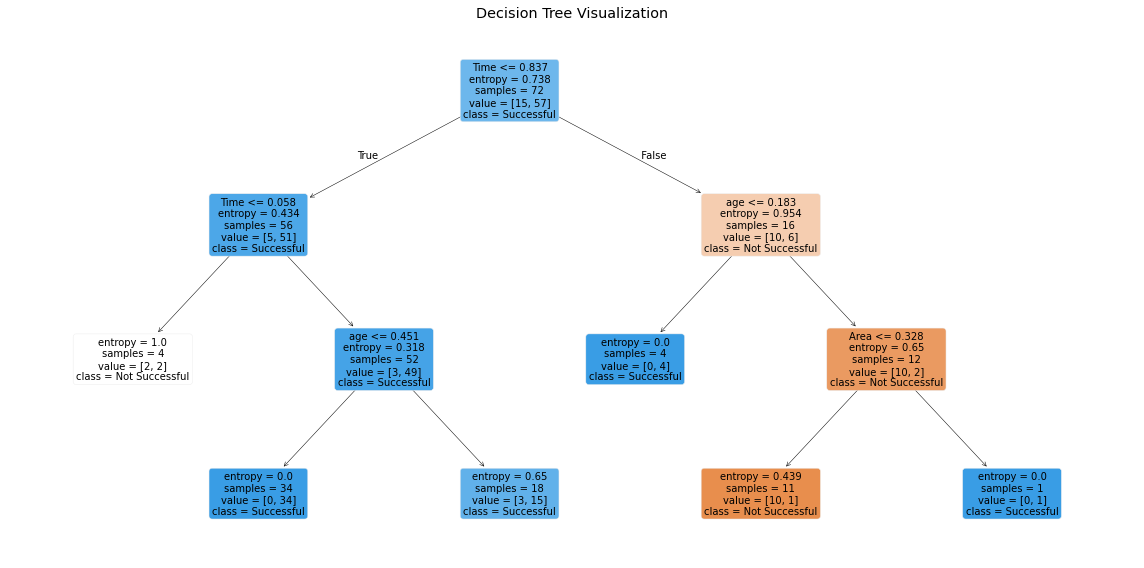

In [56]:
dt = best_pipe.named_steps['classifier']
feature_names = get_feature_names(best_pipe.named_steps['preprocessor'])

plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=feature_names, class_names=['Not Successful', 'Successful'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.savefig('decision_tree.png')
plt.show()

5. (2 points) **Evaluate performance in training and test sets.**

In [60]:
y_train_pred = best_pipe.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))


Training Accuracy: 0.9167

Training Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.95      0.95      0.95        57

    accuracy                           0.92        72
   macro avg       0.87      0.87      0.87        72
weighted avg       0.92      0.92      0.92        72



In [62]:
y_test_pred = best_pipe.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Test Accuracy: 0.8333

Test Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.87      0.93      0.90        14

    accuracy                           0.83        18
   macro avg       0.77      0.71      0.73        18
weighted avg       0.82      0.83      0.82        18



---

# Exercise 3 (20 points)

**In this problem you will be working with the [Digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).**

**Each sample corresponds to an $8 \times 8$ gray image of a handwritten digit. There is a total of 10 digits or labels ($0, 1, 2, \dots, 9$). The dataset contains 1797 samples.**

In [81]:
from sklearn.datasets import load_digits

digits = load_digits(return_X_y=False)

print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [82]:
# Obtaining data

# Each row corresponds to an image with 8x8=64 pixels/features
X = digits.data 

# Labels
t = digits.target

X.shape, t.shape

((1797, 64), (1797,))

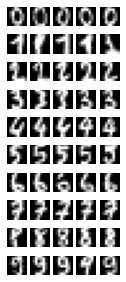

In [83]:
# displaying some examples of digits

plt.figure(figsize=(2,5))
grid_loc=1
for i in range(10):
    digits_labels_idx = np.where(t==i)[0]
    idx = np.random.randint(len(digits_labels_idx),size=5)
    for j in range(5):
        plt.subplot(10,5,grid_loc)
        plt.imshow(X[digits_labels_idx[idx[j]],:].reshape(8,8), cmap='gray')
        plt.axis('off')
        grid_loc+=1

**Answer the following questions:**

1. (2 points) **Partition the data into training and test using a stratified 80/20 partition. For reproducible, fix the value for the ```random_state``` parameter.**





In [86]:
x_train, x_test, y_train, y_test = train_test_split(X, t, test_size=0.2, random_state=2025, stratify=t)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437,), (360,))

2. (6 points) **Build a pipeline that includes data preprocessing and a random forest classifier with ```random_state=0```.**
    * **For data preprocessing, use the min-max scaler.**


In [87]:
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', RandomForestClassifier(random_state=0))
])


3. (4 points) **Carry hyperparameter tuning using grid search to experiment with number of trees, ```criterion```, ```max_depth```, ```min_samples_split``` and ```min_samples_leaf```. Train the final model pipeline.**


In [88]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],  # number of trees
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

In [89]:
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_pipe = grid_search.best_estimator_

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


4. (4 points) **Print the ```feature_importance_``` for the final model. Reshape this vector as an $8\times 8$ image and display it with ```imshow```. Discuss observations. Central pixels show highest importance, especially at position (5,2), indicating these are crucial for digit classification Edge pixels (particularly columns 0 and 7) show near-zero importance, suggesting handwritten digits rarely extend to these boundaries High-importance pixels in the middle likely help differentiate between similar digits **

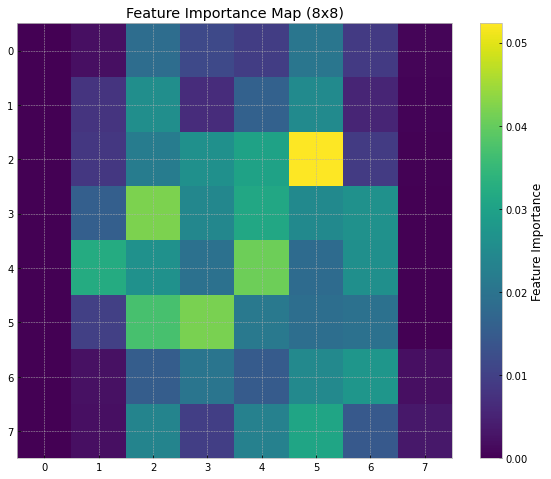

In [90]:
rf = best_pipe.named_steps['classifier']
feature_importance = rf.feature_importances_
importance_image = feature_importance.reshape(8, 8)

plt.figure(figsize=(10, 8))
plt.imshow(importance_image, cmap='viridis')
plt.colorbar(label='Feature Importance')
plt.title('Feature Importance Map (8x8)')
plt.savefig('feature_importance.png')
plt.show()


5. (4 points) **Evaluate performance in training and test sets.**

In [92]:
y_train_pred = best_pipe.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))


Training Accuracy: 1.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       145
           2       1.00      1.00      1.00       142
           3       1.00      1.00      1.00       146
           4       1.00      1.00      1.00       145
           5       1.00      1.00      1.00       146
           6       1.00      1.00      1.00       145
           7       1.00      1.00      1.00       143
           8       1.00      1.00      1.00       139
           9       1.00      1.00      1.00       144

    accuracy                           1.00      1437
   macro avg       1.00      1.00      1.00      1437
weighted avg       1.00      1.00      1.00      1437



In [93]:
y_test_pred = best_pipe.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Test Accuracy: 0.9750

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        35
           3       1.00      0.89      0.94        37
           4       1.00      0.97      0.99        36
           5       0.97      0.94      0.96        36
           6       0.97      1.00      0.99        36
           7       1.00      0.97      0.99        36
           8       0.95      1.00      0.97        35
           9       0.90      0.97      0.93        36

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



---

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___